1774868862.0721881


{'ID': '1774868862.0721881',
 'manifold_type': 'S2',
 'n_samples_ls': array([  500,  1057,  2236,  4729, 10000]),
 'M_grid': array([2, 3, 4, 5, 6, 7, 8, 9]),
 'rho_grid': array([0.001, 0.012, 0.023, 0.034, 0.045, 0.056, 0.067, 0.078, 0.089,
        0.1  ]),
 'sigma2s': array([0.005, 0.054, 0.103, 0.152, 0.201, 0.25 ]),
 'test_size': 10000,
 'num_oracle_samples': 10000,
 'NMC': 100,
 'G_names': ['2-modal', '5-modal', '10-modal', 'equator'],
 'G_params': [{'tau2': 0.075, 'num_modes': 2},
  {'tau2': 0.05, 'num_modes': 5},
  {'tau2': 0.001, 'num_modes': 10},
  {'tau2': 0.0001}]}

Selected sigma2: 0.152


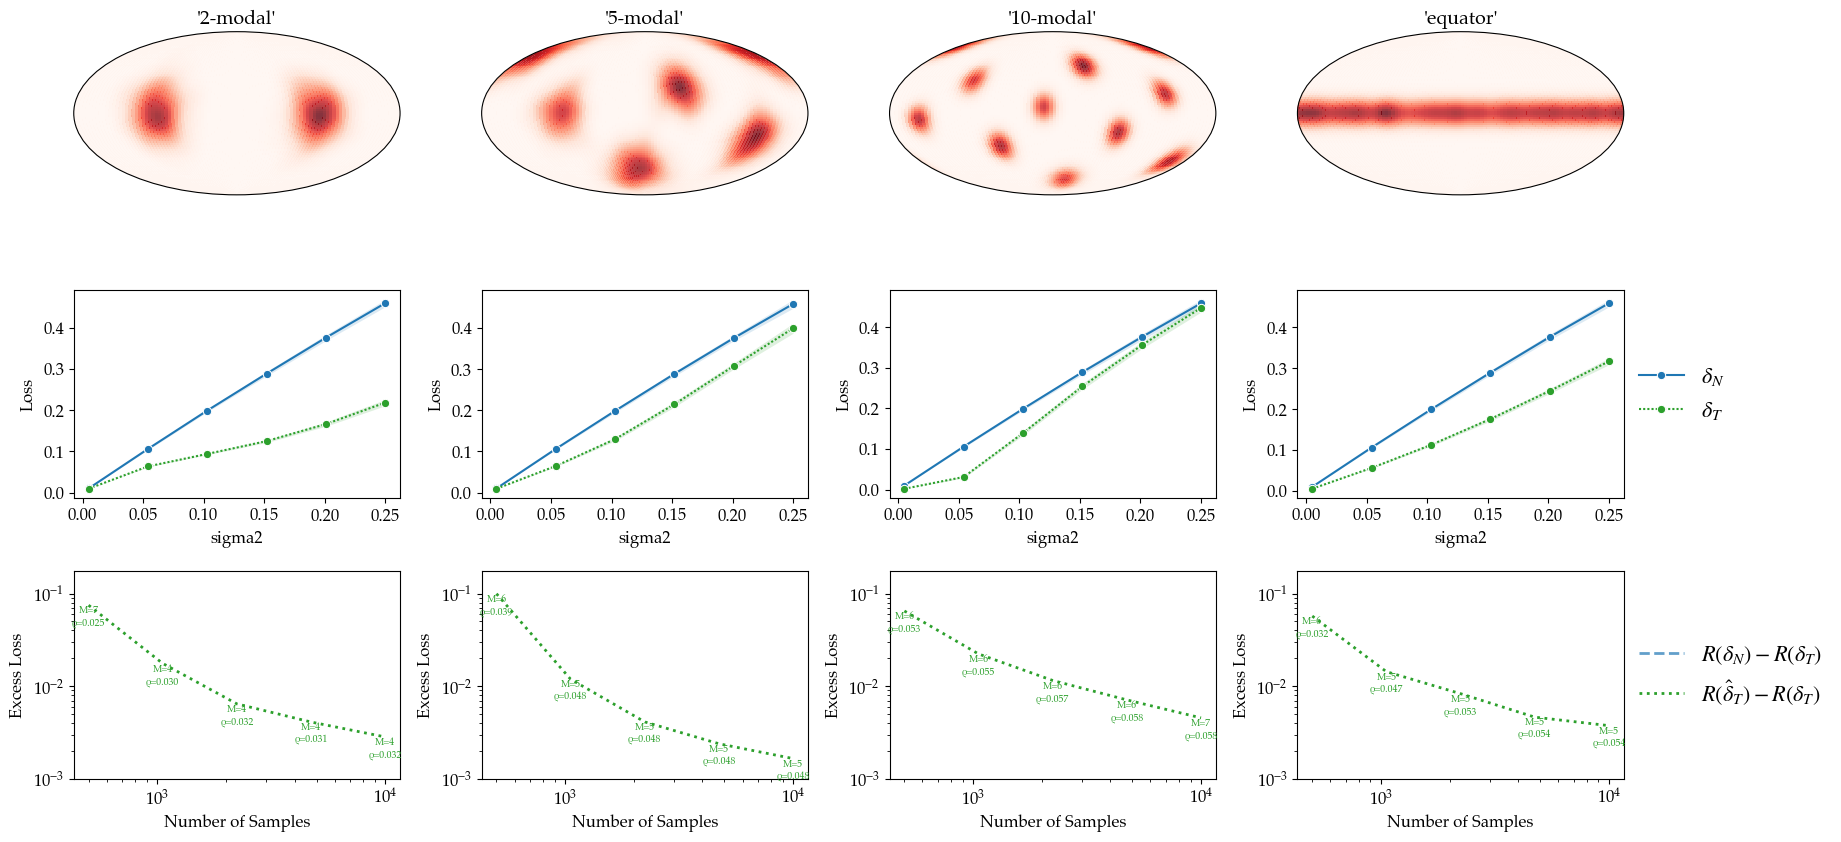

In [ ]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
manifold_type = 'S2'
params_files = sorted(f for f in os.listdir('data/' + manifold_type))
# ----- # ----- # ----- SELECT HERE ----- # ----- # ----
ID = str(params_files[-1]); print(ID)
# ----- # ----- # ----- # ----- # ----- # ---- # ----- # 
results_ocv = pd.read_csv(
    f'data/{manifold_type}/{ID}/rate_ocv.csv',
    converters={'cv_Ms_star': parse_np_array,  'cv_rhos_star': parse_np_array}
)
results_mc = pd.read_csv(f'data/{manifold_type}/{ID}/rate_mc.csv')
params = pickle.load(open(f'data/{manifold_type}/{ID}/rate_params.pkl', 'rb'))
display(params)
# -----
# plot_cv_distributions_split(results_ocv, params)
# -----
selected_sigma2=results_ocv.sigma2.unique()[3] ; print('Selected sigma2:', selected_sigma2)
plot_sims(manifold_type, results_mc, results_ocv, params, selected_sigma2, eps = .5e-3, absolute_excess_loss = False, CI = False)
# -----
# plot_mcratesims_interactive(manifold_type, results_mc, results_ocv, params, cvonly = False, eps = 1e-5)

-----